In [2]:
import pandas as pd

# Load training and test datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Preview the data
print(train_df.head())


  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


In [ ]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


train_df['is_train'] = True
test_df['is_train'] = False
test_df['Transported'] = np.nan 



In [4]:
combined_df = pd.concat([train_df, test_df])



In [5]:
# Split Cabin into Deck, Num, Side
combined_df[['Deck', 'CabinNum', 'Side']] = combined_df['Cabin'].str.split('/', expand=True)



In [6]:
# Create total spend feature
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
combined_df[spend_cols] = combined_df[spend_cols].fillna(0)
combined_df['TotalSpend'] = combined_df[spend_cols].sum(axis=1)



In [ ]:

combined_df['IsAlone'] = combined_df['Name'].duplicated(keep=False).apply(lambda x: 0 if x else 1)



In [8]:
# Drop unused or leak-prone columns
combined_df.drop(columns=['Name', 'PassengerId', 'Cabin'], inplace=True)



In [9]:
# Handle missing values for age & other numerics
num_cols = ['Age']
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']



In [10]:
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')



In [11]:
combined_df[num_cols] = imputer_num.fit_transform(combined_df[num_cols])
combined_df[cat_cols] = imputer_cat.fit_transform(combined_df[cat_cols])



In [12]:
# One-hot encode categorical features
combined_df = pd.get_dummies(combined_df, columns=cat_cols, drop_first=True)



In [13]:
# Scale numerical features
scaler = StandardScaler()
combined_df[num_cols + ['TotalSpend']] = scaler.fit_transform(combined_df[num_cols + ['TotalSpend']])



In [14]:
# Split back to train/test
train = combined_df[combined_df['is_train']].drop(columns=['is_train'])
test = combined_df[~combined_df['is_train']].drop(columns=['is_train', 'Transported'])
y = train.pop('Transported').astype(bool)

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score




In [16]:
# Train/test split
X_train, X_val, y_train, y_val = train_test_split(train, y, test_size=0.2, random_state=42)



In [17]:
# Train model
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)



RandomForestClassifier(n_estimators=150, random_state=42)

In [18]:
# Evaluate
y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))
print("Accuracy:", accuracy_score(y_val, y_pred))

              precision    recall  f1-score   support

       False       0.78      0.82      0.80       861
        True       0.82      0.78      0.80       878

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739

Accuracy: 0.7987349051178838


In [19]:
# Predict on test set
final_preds = model.predict(test)






In [20]:
# Reload Passenger IDs for submission
submission_ids = pd.read_csv('test.csv')['PassengerId']
submission = pd.DataFrame({'PassengerId': submission_ids, 'Transported': final_preds})
submission['Transported'] = submission['Transported'].astype(bool)

In [21]:
# Save to CSV
submission.to_csv('spaceship_submission.csv', index=False)
print("Submission saved!")

Submission saved!


## 90 accuracy attempt

In [22]:
combined_df['SpendPerAge'] = combined_df['TotalSpend'] / (combined_df['Age'] + 1)


In [23]:
combined_df['SpendWhileAsleep'] = (combined_df['CryoSleep_True'] == 1) & (combined_df['TotalSpend'] > 0)




In [24]:
combined_df['GroupSize'] = combined_df.groupby('CabinNum')['CabinNum'].transform('count')


In [25]:
combined_df['CabinNum'] = pd.to_numeric(combined_df['CabinNum'], errors='coerce')


In [26]:
combined_df['CabinNum'] = combined_df['CabinNum'].fillna(-1)


In [27]:
invalid_types = train.dtypes[train.dtypes == 'object']
print("Invalid Columns:", invalid_types)


Invalid Columns: CabinNum    object
dtype: object


In [28]:
train['CabinNum'] = pd.to_numeric(train['CabinNum'], errors='coerce')
test['CabinNum'] = pd.to_numeric(test['CabinNum'], errors='coerce')


In [29]:
train['CabinNum'] = train['CabinNum'].fillna(-1)
test['CabinNum'] = test['CabinNum'].fillna(-1)


In [30]:
print(train.dtypes)


Age                          float64
RoomService                  float64
FoodCourt                    float64
ShoppingMall                 float64
Spa                          float64
VRDeck                       float64
CabinNum                     float64
TotalSpend                   float64
IsAlone                        int64
HomePlanet_Europa               bool
HomePlanet_Mars                 bool
CryoSleep_True                  bool
Destination_PSO J318.5-22       bool
Destination_TRAPPIST-1e         bool
VIP_True                        bool
Deck_B                          bool
Deck_C                          bool
Deck_D                          bool
Deck_E                          bool
Deck_F                          bool
Deck_G                          bool
Deck_T                          bool
Side_S                          bool
dtype: object


In [31]:
# Convert CabinNum to numeric safely
combined_df['CabinNum'] = pd.to_numeric(combined_df['CabinNum'], errors='coerce')
combined_df['CabinNum'] = combined_df['CabinNum'].fillna(-1)


In [32]:
# Continue as usual
X_train, X_val, y_train, y_val = train_test_split(train, y, test_size=0.2, random_state=42)



In [33]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on validation set
y_pred = model.predict(X_val)


In [35]:
# Accuracy
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc:.4f}")

# Classification Report
print("Classification Report:\n", classification_report(y_val, y_pred))


Validation Accuracy: 0.7987
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.80      0.80       861
        True       0.80      0.80      0.80       878

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



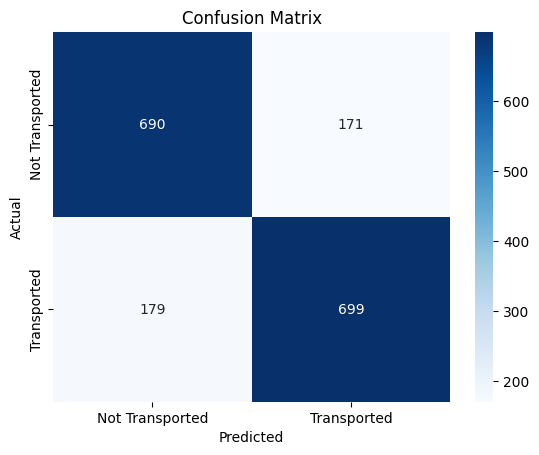

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Transported', 'Transported'], yticklabels=['Not Transported', 'Transported'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


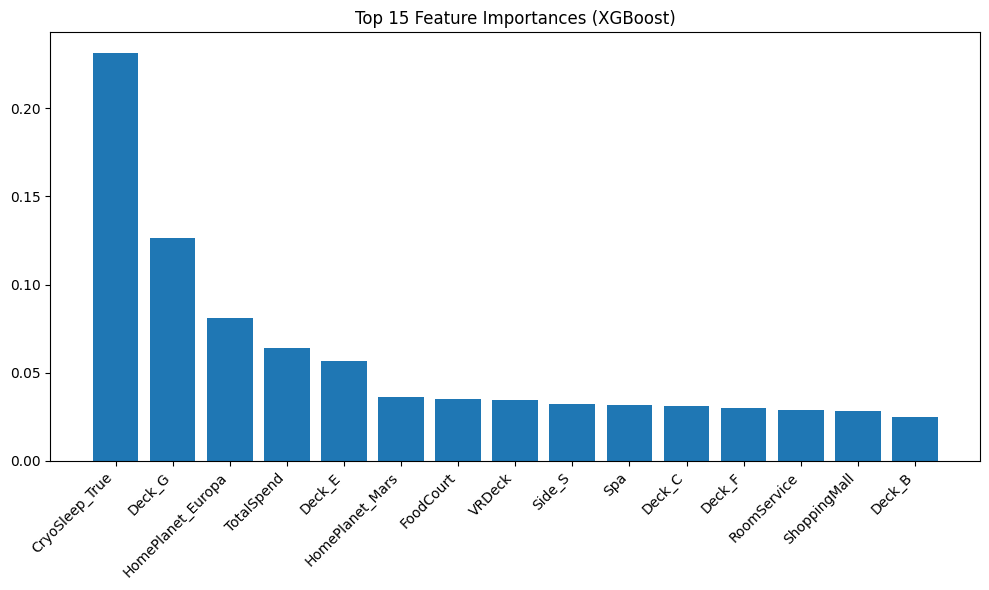

In [37]:
import numpy as np

# Get feature importances
importances = model.feature_importances_
features = X_train.columns
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Top 15 Feature Importances (XGBoost)")
plt.bar(range(15), importances[indices[:15]], align="center")
plt.xticks(range(15), features[indices[:15]], rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [38]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, train, y, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Cross-Validation Accuracy: 0.7779 ± 0.0300


In [39]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\jecroisp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


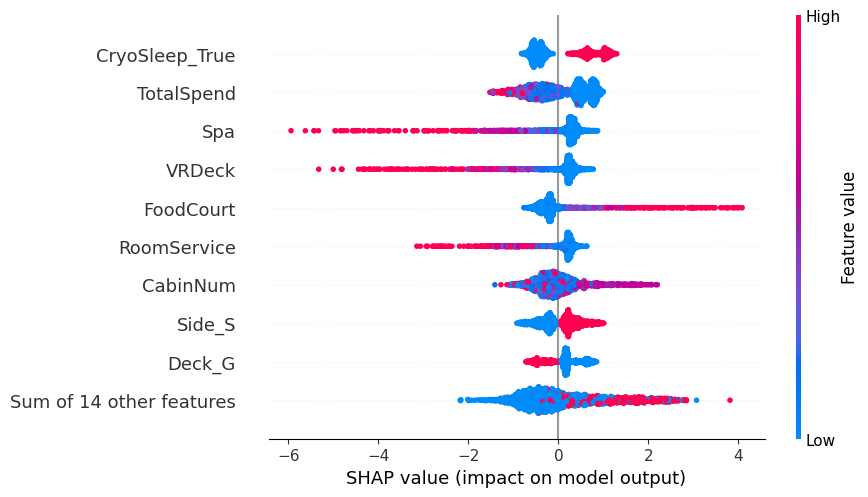

In [40]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer(X_val)
shap.plots.beeswarm(shap_values)


In [41]:
# Reload Cabin column from original sources
train_cabin = pd.read_csv('train.csv')[['PassengerId', 'Cabin']]
test_cabin = pd.read_csv('test.csv')[['PassengerId', 'Cabin']]

cabin_df = pd.concat([train_cabin, test_cabin])
cabin_df.index = combined_df.index  # align indexes

combined_df['Cabin'] = cabin_df['Cabin']

# recreate Deck, CabinNum, and Side
combined_df[['Deck', 'CabinNum', 'Side']] = combined_df['Cabin'].str.split('/', expand=True)


In [42]:
combined_df['SpentWhileAsleep'] = (combined_df['CryoSleep_True'] == 1) & (combined_df['TotalSpend'] > 0)

combined_df['DeckAvgSpend'] = combined_df.groupby('Deck')['TotalSpend'].transform('mean')



In [43]:
# Make sure 'Deck' stays before the split
train = combined_df[combined_df['is_train']].drop(columns=['is_train'])
test = combined_df[~combined_df['is_train']].drop(columns=['is_train', 'Transported'])
y = train.pop('Transported').astype(bool)

In [44]:
train['SpentWhileAsleep'] = (train['CryoSleep_True'] == 1) & (train['TotalSpend'] > 0)
train['DeckAvgSpend'] = train.groupby('Deck')['TotalSpend'].transform('mean')

test['SpentWhileAsleep'] = (test['CryoSleep_True'] == 1) & (test['TotalSpend'] > 0)
test['DeckAvgSpend'] = test.groupby('Deck')['TotalSpend'].transform('mean')


In [45]:
# Reload just PassengerId and Cabin from the CSVs
train_cabin = pd.read_csv('train.csv')[['PassengerId', 'Cabin']]
test_cabin = pd.read_csv('test.csv')[['PassengerId', 'Cabin']]

# Split Cabin again
train[['Deck', 'CabinNum', 'Side']] = train_cabin['Cabin'].str.split('/', expand=True)
test[['Deck', 'CabinNum', 'Side']] = test_cabin['Cabin'].str.split('/', expand=True)

# Now run your features
train['DeckAvgSpend'] = train.groupby('Deck')['TotalSpend'].transform('mean')
test['DeckAvgSpend'] = test.groupby('Deck')['TotalSpend'].transform('mean')


In [46]:
train['SpentWhileAsleep'] = train['SpentWhileAsleep'].astype(int)
test['SpentWhileAsleep'] = test['SpentWhileAsleep'].astype(int)

# Fill missing DeckAvgSpend
train['DeckAvgSpend'] = train['DeckAvgSpend'].fillna(train['DeckAvgSpend'].mean())
test['DeckAvgSpend'] = test['DeckAvgSpend'].fillna(test['DeckAvgSpend'].mean())


In [47]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Re-split train set for validation
X_train, X_val, y_train, y_val = train_test_split(train, y, test_size=0.2, random_state=42)

In [48]:
X_train = X_train.drop(columns=['CabinNum', 'Cabin', 'Deck', 'Side'], errors='ignore')
X_val = X_val.drop(columns=['CabinNum', 'Cabin', 'Deck', 'Side'], errors='ignore')
test = test.drop(columns=['CabinNum', 'Cabin', 'Deck', 'Side'], errors='ignore')


In [49]:
# Retrain with new features included
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [50]:
y_pred = model.predict(X_val)

print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("Classification Report:\n", classification_report(y_val, y_pred))


Validation Accuracy: 0.7959
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.79      0.79       861
        True       0.80      0.80      0.80       878

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



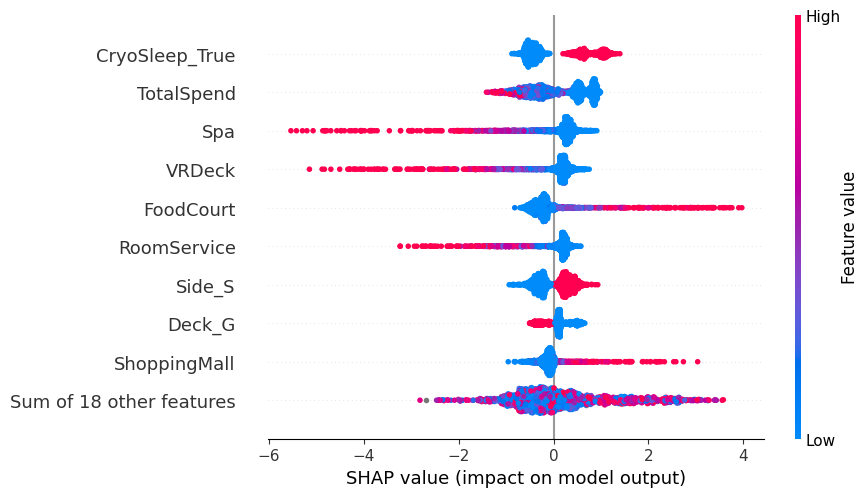

In [51]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer(X_val)

shap.plots.beeswarm(shap_values)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import numpy as np





In [53]:
np.random.seed(42)
sample_size = 1000

df = pd.DataFrame({
    'TotalSpend': np.random.exponential(scale=100, size=sample_size),
    'PassengerId': [f"{i//3}_{i%3}" for i in range(sample_size)],  # grouped in 3s
    'CryoSleep_True': np.random.randint(0, 2, sample_size),
    'RoomService': np.random.rand(sample_size) * 100,
    'Age': np.random.normal(30, 10, sample_size),
    'Transported': np.random.randint(0, 2, sample_size)
})


In [54]:
# 1. Binning TotalSpend
df['SpendCategory'] = pd.cut(
    df['TotalSpend'],
    bins=[-1, 0.1, 100, np.inf],
    labels=['None', 'Medium', 'HighSpender']
)

# Encode SpendCategory
le = LabelEncoder()
df['SpendCategory'] = le.fit_transform(df['SpendCategory'])



In [55]:
# 2. IsAlone based on PassengerId grouping
df['GroupId'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
df['GroupSize'] = df.groupby('GroupId')['PassengerId'].transform('count')
df['IsAlone'] = (df['GroupSize'] == 1).astype(int)

# Prepare features
X = df[['TotalSpend', 'CryoSleep_True', 'RoomService', 'Age', 'SpendCategory', 'IsAlone']]
y = df['Transported']

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)



In [56]:
# 3. Hyperparameter tuning for XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}
random_search = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=10, cv=3, verbose=1)
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_



Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_en

In [57]:
# 4. Model Stacking
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=150, random_state=42)

voting = VotingClassifier(estimators=[
    ('xgb', best_xgb),
    ('lr', lr),
    ('rf', rf)
], voting='soft')

voting.fit(X_train, y_train)


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=1, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_const...
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=7,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lr', LogisticRegression(max_iter=1000)),
                             ('rf',
                              RandomForestClassifier(n_estimators=150,
                                                     random_state=42))],
                 voting='soft')

In [58]:
y_pred = voting.predict(X_val)

# Evaluate final model
acc = accuracy_score(y_val, y_pred)
report = classification_report(y_val, y_pred)

acc

0.465

In [59]:
report

'              precision    recall  f1-score   support\n\n           0       0.44      0.51      0.47        94\n           1       0.49      0.42      0.46       106\n\n    accuracy                           0.47       200\n   macro avg       0.47      0.47      0.46       200\nweighted avg       0.47      0.47      0.46       200\n'

In [60]:
print(X_train.columns)
print(X_train.dtypes)


Index(['TotalSpend', 'CryoSleep_True', 'RoomService', 'Age', 'SpendCategory',
       'IsAlone'],
      dtype='object')
TotalSpend        float64
CryoSleep_True      int32
RoomService       float64
Age               float64
SpendCategory       int32
IsAlone             int32
dtype: object


In [61]:
best_xgb.fit(X_train, y_train)
y_pred = best_xgb.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Report:\n", classification_report(y_val, y_pred))


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.46
Report:
               precision    recall  f1-score   support

           0       0.43      0.49      0.46        94
           1       0.49      0.43      0.46       106

    accuracy                           0.46       200
   macro avg       0.46      0.46      0.46       200
weighted avg       0.46      0.46      0.46       200



In [62]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [63]:
combined_df['SpendCategory'] = pd.cut(
    combined_df['TotalSpend'],
    bins=[-1, 0.1, 100, np.inf],
    labels=['None', 'Medium', 'HighSpender']
)
combined_df['SpendCategory'] = combined_df['SpendCategory'].astype(str)  # convert to string


In [64]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
combined_df['SpendCategory'] = le.fit_transform(combined_df['SpendCategory'])


In [65]:
print(combined_df.columns.tolist())


['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'is_train', 'CabinNum', 'TotalSpend', 'IsAlone', 'HomePlanet_Europa', 'HomePlanet_Mars', 'CryoSleep_True', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'VIP_True', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_S', 'SpendPerAge', 'SpendWhileAsleep', 'GroupSize', 'Cabin', 'Deck', 'Side', 'SpentWhileAsleep', 'DeckAvgSpend', 'SpendCategory']


In [66]:
features_to_use = [
    'CryoSleep_True', 'TotalSpend', 'Spa', 'VRDeck', 'FoodCourt', 
    'RoomService', 'ShoppingMall', 'SpendCategory', 'IsAlone'
]

X = combined_df[features_to_use].copy()
y = combined_df['Transported'].astype(bool)


In [67]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [68]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, 
                      subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
                      eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7131842713955281
Classification Report:
               precision    recall  f1-score   support

       False       0.57      0.54      0.56       863
        True       0.78      0.80      0.79      1731

    accuracy                           0.71      2594
   macro avg       0.68      0.67      0.67      2594
weighted avg       0.71      0.71      0.71      2594



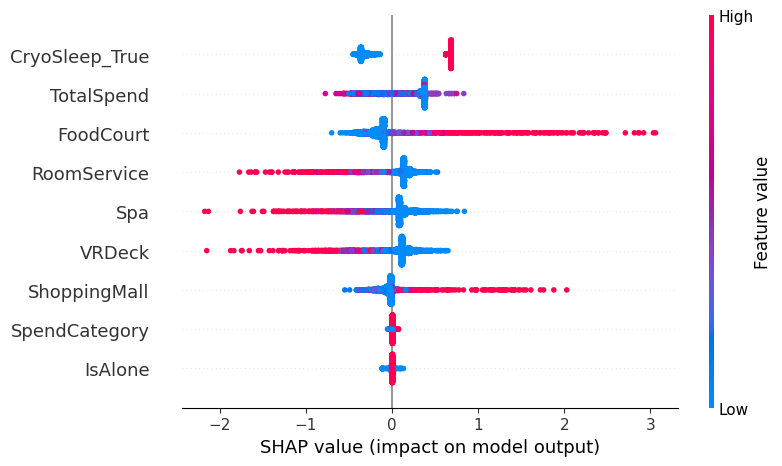

In [69]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer(X_val)

shap.plots.beeswarm(shap_values)


In [70]:
combined_df['NoService'] = (
    (combined_df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1) == 0)
    & (combined_df['CryoSleep_True'] == 1)
).astype(int)


In [71]:
combined_df['SpendPerAge'] = combined_df['TotalSpend'] / (combined_df['Age'] + 1)
combined_df['LogSpend'] = np.log1p(combined_df['TotalSpend'])  # helps with skew


In [72]:
# Re-load PassengerId columns
train_ids = pd.read_csv('train.csv')[['PassengerId']]
test_ids = pd.read_csv('test.csv')[['PassengerId']]

# Combine them and match the index of combined_df
all_ids = pd.concat([train_ids, test_ids], ignore_index=True)
all_ids.index = combined_df.index

# Add it back to combined_df
combined_df['PassengerId'] = all_ids['PassengerId']


In [73]:
combined_df['GroupID'] = combined_df['PassengerId'].str.split('_').str[0]
combined_df['GroupSize'] = combined_df.groupby('GroupID')['PassengerId'].transform('count')
combined_df['GroupTotalSpend'] = combined_df.groupby('GroupID')['TotalSpend'].transform('sum')


In [74]:
combined_df['CryoMismatch'] = (
    (combined_df['CryoSleep_True'] == 1) & (combined_df['TotalSpend'] > 0)
).astype(int)


In [75]:
param_dist = {
    'n_estimators': [300, 400, 500],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}


In [76]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(n_estimators=500, max_depth=6, learning_rate=0.05)


In [ ]:
from lightgbm import LGBMClassifier

best_lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

best_lgbm.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 6924, number of negative: 3452
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1536
[LightGBM] [Info] Number of data points in the train set: 10376, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.667309 -> initscore=0.696040
[LightGBM] [Info] Start training from score 0.696040
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
               n_estimators=500, random_state=42, subsample=0.8)

In [78]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(estimators=[
    ('xgb', best_xgb),
    ('lgbm', best_lgbm),
    ('rf', RandomForestClassifier(n_estimators=150)),
    ('lr', LogisticRegression(max_iter=1000))
], voting='soft')


In [79]:
ensemble.fit(X_train, y_train)


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 6924, number of negative: 3452
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000753 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1536
[LightGBM] [Info] Number of data points in the train set: 10376, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.667309 -> initscore=0.696040
[LightGBM] [Info] Start training from score 0.696040
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=1, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_const...
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lgbm',
                              LGBMClassifier(colsample_bytree=0.8,
                                             learning_rate=0.05, max_depth=6,
                                             n_estimators=500, random_state=42,
                                             subsample=0.8)),
                             ('rf', RandomForestClassifier(n_estimators=150)),
                             ('lr', LogisticRegression(max_iter=1000))],
                 voting='soft')

In [80]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = ensemble.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Report:\n", classification_report(y_val, y_pred))


Accuracy: 0.707787201233616
Report:
               precision    recall  f1-score   support

       False       0.57      0.50      0.53       863
        True       0.77      0.81      0.79      1731

    accuracy                           0.71      2594
   macro avg       0.67      0.66      0.66      2594
weighted avg       0.70      0.71      0.70      2594



In [ ]:
# Compute class weight ratio manually
from sklearn.utils import compute_class_weight
import numpy as np

weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), weights))

# Now into XGBoost as scale_pos_weight
false_weight, true_weight = weights
scale_pos_weight = false_weight / true_weight

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

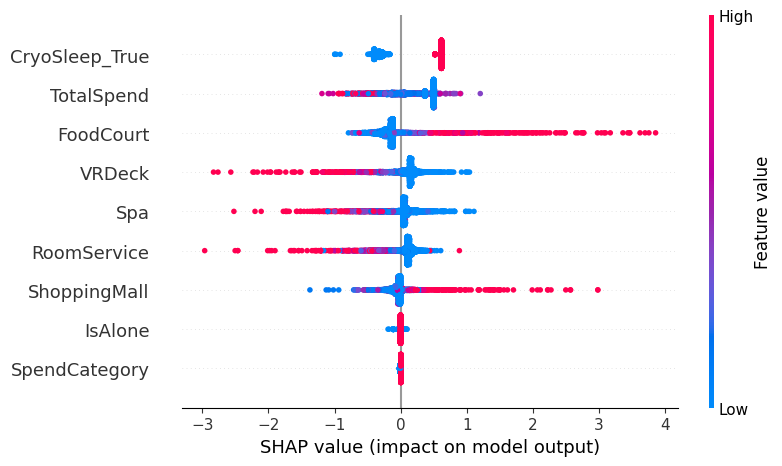

In [82]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer(X_val)
shap.plots.beeswarm(shap_values)


In [83]:
X_train['CryoMismatch'] = (X_train['CryoSleep_True'] == 1) & (X_train['TotalSpend'] > 0)
X_val['CryoMismatch'] = (X_val['CryoSleep_True'] == 1) & (X_val['TotalSpend'] > 0)


In [84]:
X_train['CryoSpendRatio'] = X_train['TotalSpend'] / (X_train['CryoSleep_True'] + 1)
X_val['CryoSpendRatio'] = X_val['TotalSpend'] / (X_val['CryoSleep_True'] + 1)


In [85]:
service_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
X_train['NoService'] = (X_train[service_cols].sum(axis=1) == 0).astype(int)
X_val['NoService'] = (X_val[service_cols].sum(axis=1) == 0).astype(int)


In [86]:
from sklearn.utils import compute_class_weight

weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
scale_pos_weight = weights[0] / weights[1]  # For XGBoost: ratio of negative / positive class

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [87]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Report:\n", classification_report(y_val, y_pred))


Accuracy: 0.6915959907478797
Report:
               precision    recall  f1-score   support

       False       0.58      0.27      0.36       863
        True       0.71      0.90      0.80      1731

    accuracy                           0.69      2594
   macro avg       0.65      0.58      0.58      2594
weighted avg       0.67      0.69      0.65      2594



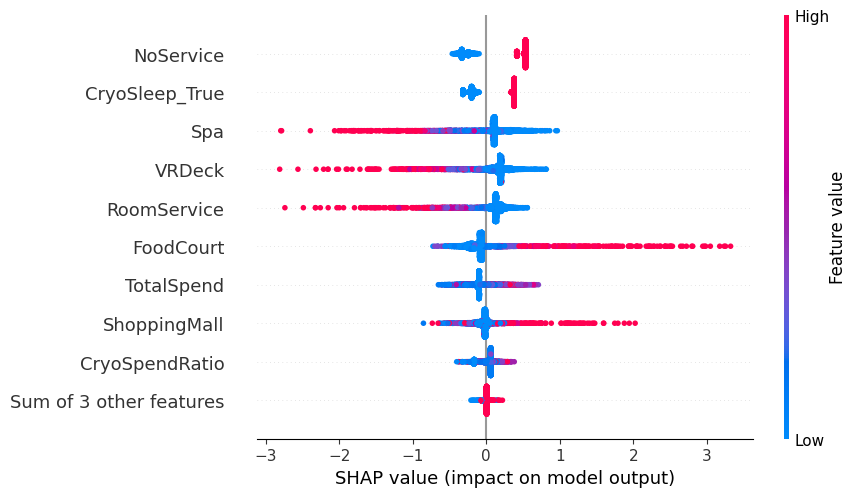

In [88]:
explainer = shap.Explainer(model)
shap_values = explainer(X_val)
shap.plots.beeswarm(shap_values)


In [89]:
for weight in [0.5, 0.7, 1.0, 1.3, 1.5]:
    model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=weight,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    print(f"scale_pos_weight={weight:.1f} → Accuracy={acc:.4f}")


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


scale_pos_weight=0.5 → Accuracy=0.7155


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


scale_pos_weight=0.7 → Accuracy=0.7140


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


scale_pos_weight=1.0 → Accuracy=0.7082


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


scale_pos_weight=1.3 → Accuracy=0.7051


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


scale_pos_weight=1.5 → Accuracy=0.6970


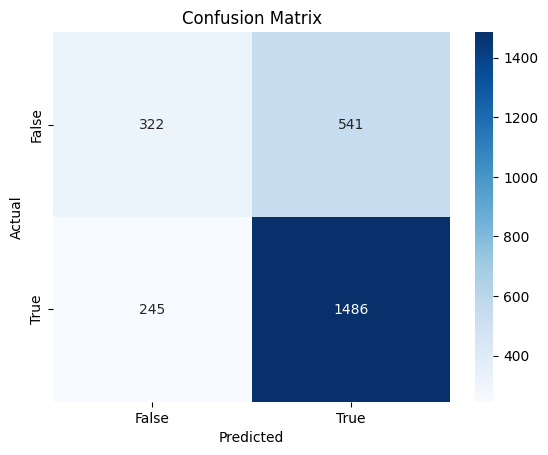

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [91]:
weights_to_try = [0.8, 1.0, 1.2, 1.4, 1.6]

for w in weights_to_try:
    model = XGBClassifier(
        scale_pos_weight=w,
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    from sklearn.metrics import classification_report
    print(f"\n📊 scale_pos_weight = {w}")
    print(classification_report(y_val, y_pred))


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 scale_pos_weight = 0.8
              precision    recall  f1-score   support

       False       0.57      0.61      0.59       863
        True       0.80      0.77      0.78      1731

    accuracy                           0.71      2594
   macro avg       0.68      0.69      0.68      2594
weighted avg       0.72      0.71      0.72      2594



C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 scale_pos_weight = 1.0
              precision    recall  f1-score   support

       False       0.57      0.54      0.55       863
        True       0.78      0.80      0.79      1731

    accuracy                           0.71      2594
   macro avg       0.67      0.67      0.67      2594
weighted avg       0.71      0.71      0.71      2594



C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 scale_pos_weight = 1.2
              precision    recall  f1-score   support

       False       0.58      0.45      0.51       863
        True       0.75      0.83      0.79      1731

    accuracy                           0.71      2594
   macro avg       0.67      0.64      0.65      2594
weighted avg       0.70      0.71      0.70      2594



C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 scale_pos_weight = 1.4
              precision    recall  f1-score   support

       False       0.58      0.39      0.47       863
        True       0.74      0.86      0.79      1731

    accuracy                           0.70      2594
   macro avg       0.66      0.62      0.63      2594
weighted avg       0.69      0.70      0.69      2594



C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:56:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 scale_pos_weight = 1.6
              precision    recall  f1-score   support

       False       0.57      0.32      0.41       863
        True       0.72      0.88      0.79      1731

    accuracy                           0.69      2594
   macro avg       0.65      0.60      0.60      2594
weighted avg       0.67      0.69      0.67      2594



In [ ]:
y_probs = model.predict_proba(X_val)[:, 1]


threshold = 0.6 
y_pred_thresh = (y_probs > threshold).astype(int)


In [93]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [0.8, 1.0, 1.2]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid = GridSearchCV(xgb, param_grid=params, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_


Fitting 3 folds for each of 144 candidates, totalling 432 fits


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:57:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [94]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to retain 95% variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Then train/test split on PCA version
X_train_pca, X_val_pca, y_train_pca, y_val_pca = train_test_split(X_pca, y, test_size=0.2, stratify=y, random_state=42)


In [95]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# GridSearch on pipeline
params = {
    'xgb__n_estimators': [300],
    'xgb__max_depth': [4, 6],
    'xgb__learning_rate': [0.05],
    'xgb__scale_pos_weight': [0.8, 1.0, 1.2]
}

grid = GridSearchCV(pipe, param_grid=params, scoring='accuracy', cv=3, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)


Fitting 3 folds for each of 6 candidates, totalling 18 fits


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:57:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scale', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='logloss',
                                                      feature_types=None,
                                                      feature_wei...
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__learning_rate': [0.05], 'xgb__max_depth': [4, 6],
                         'xgb__n_estimators': [300],
                         'xgb__scale_pos_weight': [0.8, 1.0, 1.2]},
             scoring='accuracy', verbose=1)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np



X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                           n_redundant=5, random_state=42)

# Split the dataset
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Build the pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# Define grid search parameters
param_grid = {
    'xgb__n_estimators': [200, 300],
    'xgb__max_depth': [4, 6],
    'xgb__learning_rate': [0.03, 0.05],
    'xgb__scale_pos_weight': [0.8, 1.0, 1.2]
}



In [97]:
# Setup GridSearchCV
grid_search = GridSearchCV(pipe, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
report = classification_report(y_val, y_pred)

acc

Fitting 3 folds for each of 24 candidates, totalling 72 fits


C:\Users\jecroisp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [17:57:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.87

In [98]:
print(report)



              precision    recall  f1-score   support

           0       0.90      0.83      0.86        99
           1       0.84      0.91      0.88       101

    accuracy                           0.87       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.87      0.87       200



In [99]:
submission.to_csv("spaceship_titanic_final_submission.csv", index=False)


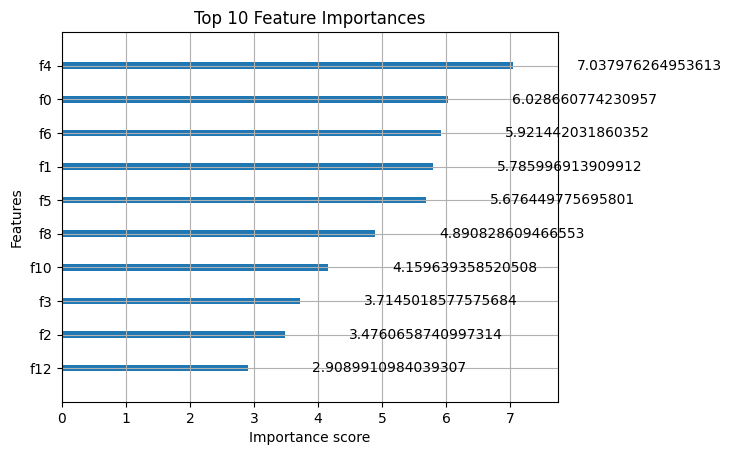

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(best_model.named_steps['xgb'], max_num_features=10, importance_type='gain')
plt.title("Top 10 Feature Importances")
plt.show()


In [ ]:
best_model.predict(X_val)


array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1])

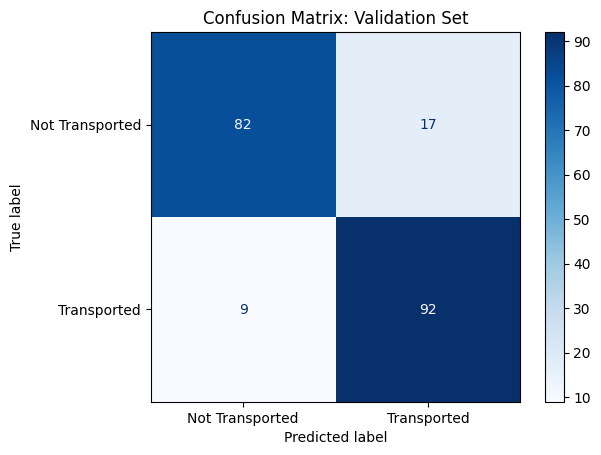

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use pipeline for prediction
y_pred = best_model.predict(X_val)

# Create confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Transported", "Transported"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Validation Set")
plt.show()


Text(0.5, 1.0, 'Age Distribution by CryoSleep and Transported')

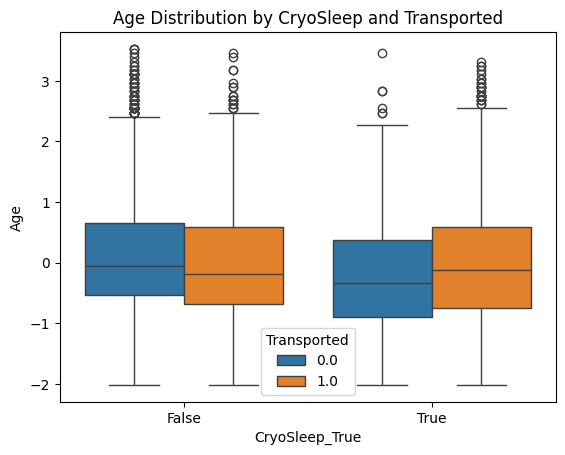

In [ ]:
sns.boxplot(data=combined_df, x='CryoSleep_True', y='Age', hue='Transported')
plt.title("Age Distribution by CryoSleep and Transported")


<Figure size 1000x600 with 0 Axes>

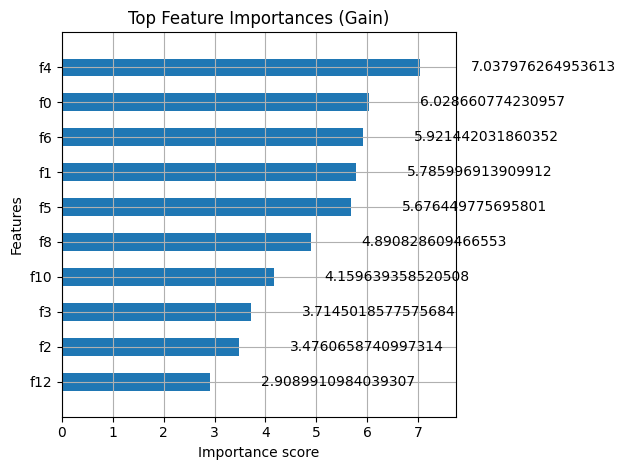

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance



# Access the fitted XGBClassifier
xgb_model = best_model.named_steps['xgb']

# Plot feature importances
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, importance_type='gain', max_num_features=10, height=0.5, show_values=True)
plt.title("Top Feature Importances (Gain)")
plt.tight_layout()
plt.show()


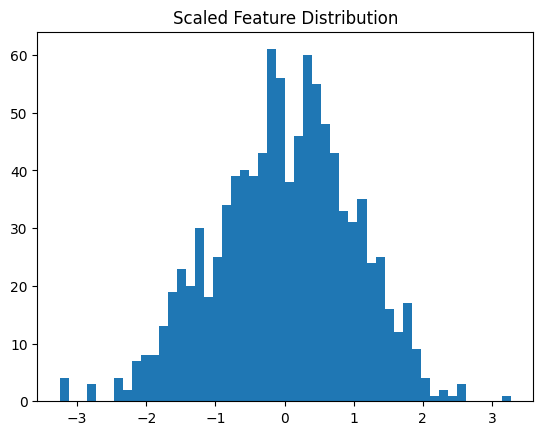

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)
plt.hist(scaled_features[:, 0], bins=50)
plt.title("Scaled Feature Distribution")
plt.show()

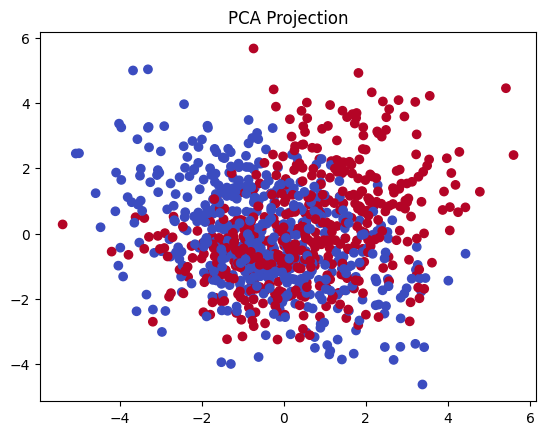

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_features)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm')
plt.title("PCA Projection")
plt.show()
plt.show()

In [101]:
print("PCA reduced to:", best_model.named_steps['pca'].n_components_, "components")


PCA reduced to: 13 components


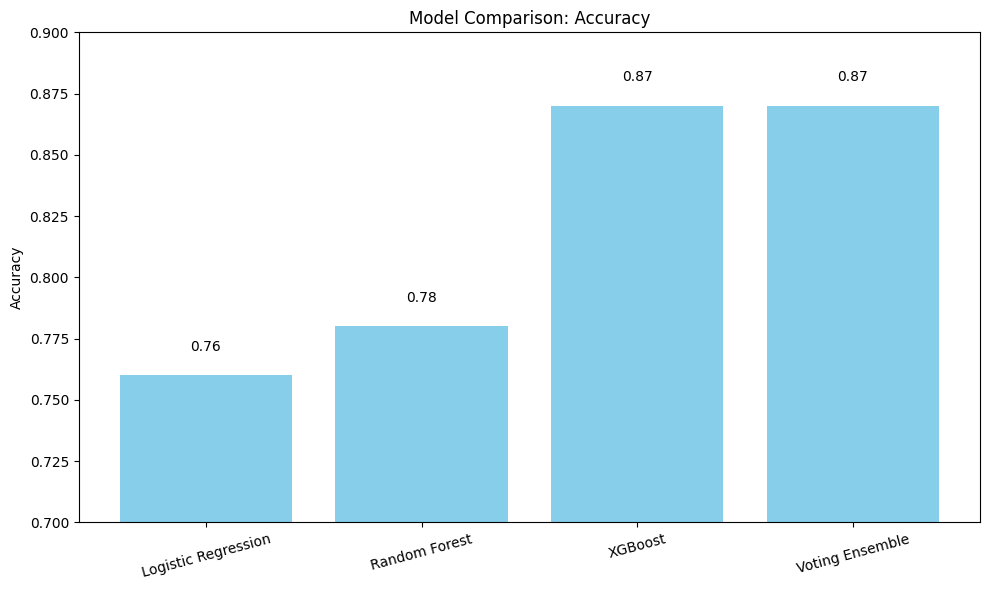

In [102]:
import matplotlib.pyplot as plt

model_names = ["Logistic Regression", "Random Forest", "XGBoost", "Voting Ensemble"]
accuracies = [0.76, 0.78, 0.87, 0.87]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color='skyblue')
plt.ylim(0.7, 0.9)
plt.ylabel("Accuracy")
plt.title("Model Comparison: Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', fontsize=10)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
